# CREATE CLASSIFICATION DATA

In [1]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

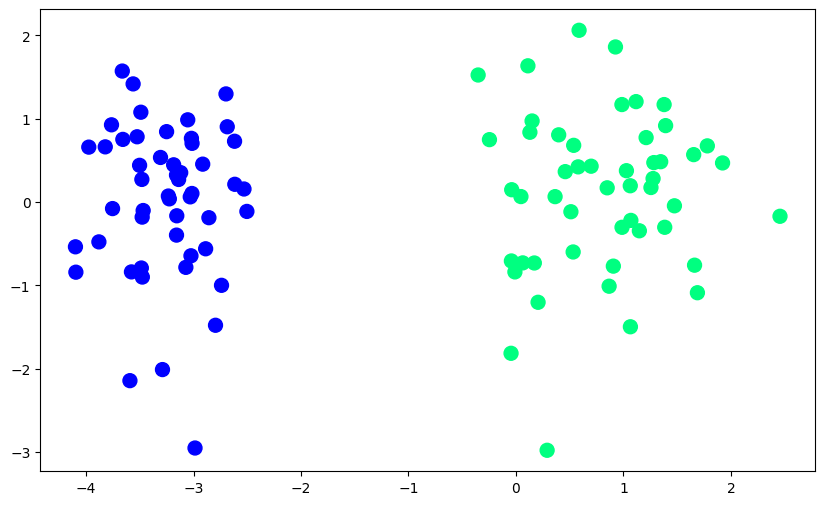

In [2]:
# PLOT THE CLASSIFICATION DATA
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.show()

# CREATE OUR OWN PERCEPTRON CODE CLASS

In [3]:
def perceptron(X,y):
    # ADD ONES IN INPUT COLUMNS
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
      # SELECT RANDOM STUDENT FROM 100
        j = np.random.randint(0,100)
        # CALCULATE OUR PREDECTION VALUE BY DEFINING STEP FUNCTION
        y_hat = step(np.dot(X[j],weights))
        # UPDATE WEIGHTS (COEFFICIENTS)
        weights = weights + lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]

In [4]:
def step(z):
    return 1 if z>0 else 0

In [5]:
intercept_,coef_ = perceptron(X,y)
print(coef_)
print(intercept_)

[1.0580085  0.40381514]
1.2000000000000002


# TO SHOW THE CLASSIFICATION LINE

In [6]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [7]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

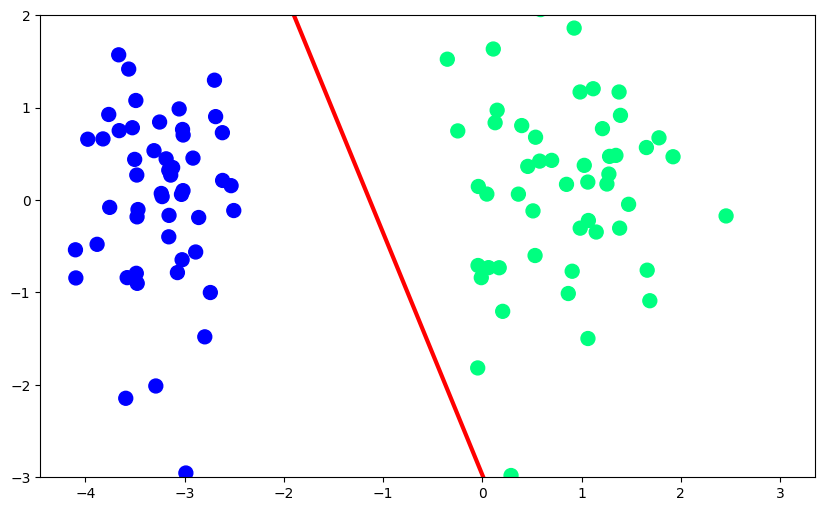

In [8]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

# TO SHOW ANIMATION (of perceptron trick)

In [9]:
def perceptron(X,y):

    m = []
    b = []

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))

    return m,b

In [10]:
m,b = perceptron(X,y)

In [11]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [12]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax
anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)
#anim.save("animation.mp4")
plt.show()

<IPython.core.display.Javascript object>

In [13]:
#from google.colab import files
#files.download("animation.mp4")

# BY LOGISTIC REGRESSION

In [14]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [15]:
lor.intercept_

array([3.13649441])

In [16]:
lor.coef_

array([[2.36687798, 0.02178765]])

# To show logistic regression line and perceptron trick line

In [17]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [18]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

In [19]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.show()

<IPython.core.display.Javascript object>

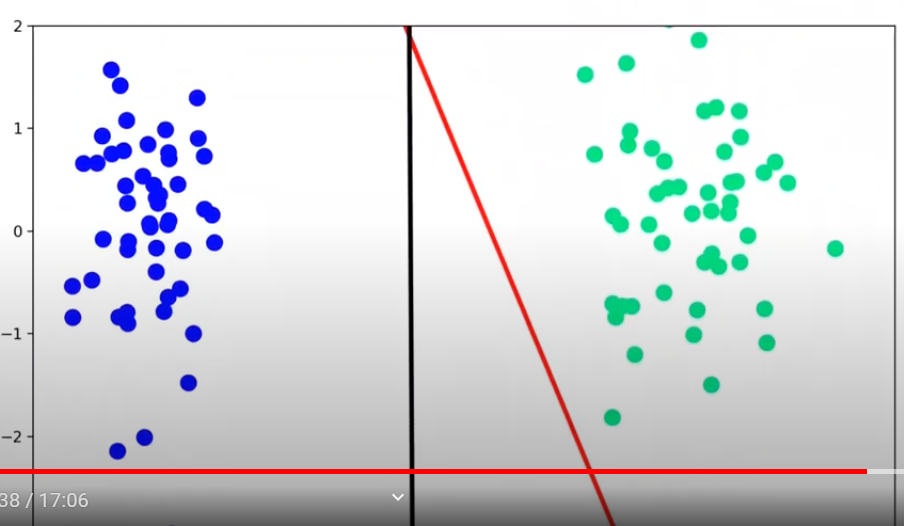

**the logistic regression works better than perceptron trick because it divides the data more symmetrically while perceptron trick only works till the relocation of wrongly classified ppints,it does not improve furthur!**

#Logistic Regression | Sigmoid Function

In [20]:
def perceptron(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]

In [21]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [22]:
intercept_,coef_ = perceptron(X,y)

In [23]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [24]:
x_input2 = np.linspace(-3,3,100)
y_input2 = m*x_input + b

In [25]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input2,y_input2,color='brown',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

<IPython.core.display.Javascript object>

(-3.0, 2.0)

**The results are improved but not completely**

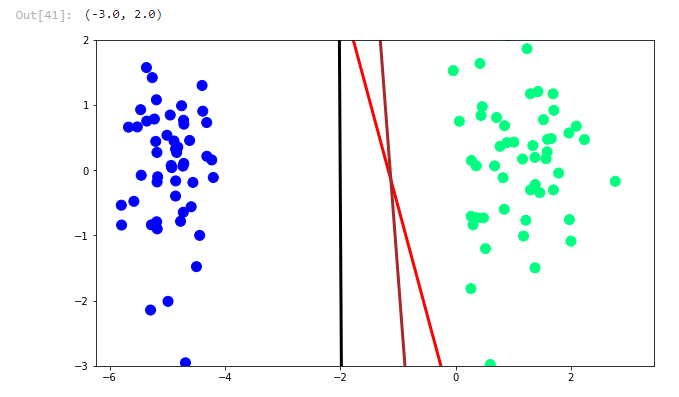